## NAIVE BAYES (Gaussian)

Algoritmo de de aprendizaje automatico supervisado
Estaba basado bajo el teorema de Bayes que usa para resolver problemas de clasificacion

Variables entrada = input / datos / caracteristicas 



In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as ss
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB  # el modelo naive bayes 
 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, roc_auc_score
 
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
# data =pd.read_csv('dataf_tips.csv') 
# aca se muestra data ser final entrenada 

In [19]:
datap = sns.load_dataset('tips')

In [20]:
datap.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [21]:
# se muestra el tipo de dato de cada columna 
datap.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

## preparar variables 

In [23]:
# para convervir smoker yes / no a 0 - 1 
le = LabelEncoder()
datap['smoker'] = le.fit_transform(datap['smoker'])

print('Clases codificadas: ',list(le.classes_), '->', list(range(len(le.classes_))))
datap[['smoker']].head()

Clases codificadas:  ['No', 'Yes'] -> [0, 1]


,smoker
0,0
1,0
2,0
3,0
4,0


In [25]:
# convertir en objetc a variables sex 
datap['sex'] = datap.sex.astype(object)

In [26]:
datap.dtypes

total_bill     float64
tip            float64
sex             object
smoker           int64
day           category
time          category
size             int64
dtype: object

### ANALISIS EXPLORATORIO (EDA ) 

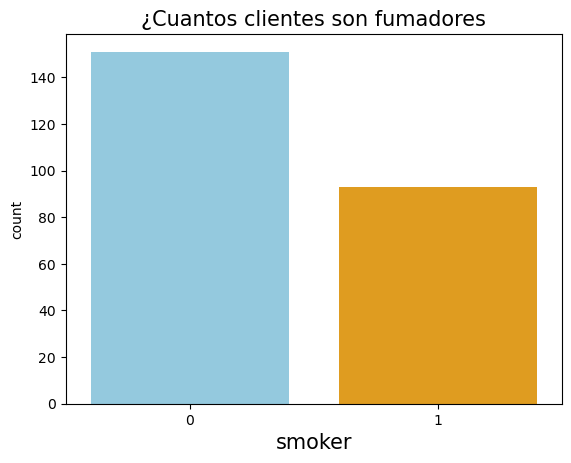

In [28]:
sns.countplot(
    data=datap,
    x='smoker',
    hue='smoker',
    palette=['skyblue','orange'],
    legend = False
)

plt.xlabel('smoker', fontsize=15)
plt.title('¿Cuantos clientes son fumadores',fontsize=15)
plt.show()

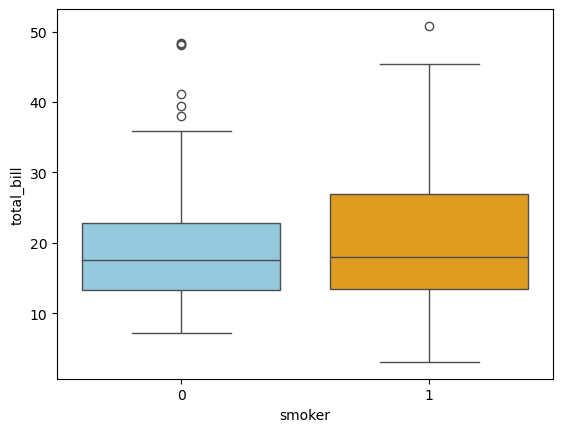

In [29]:
sns.boxplot(x='smoker', y='total_bill', data=datap,
           hue='smoker',
           palette=['skyblue', 'orange'],
           legend=False)
plt.show()

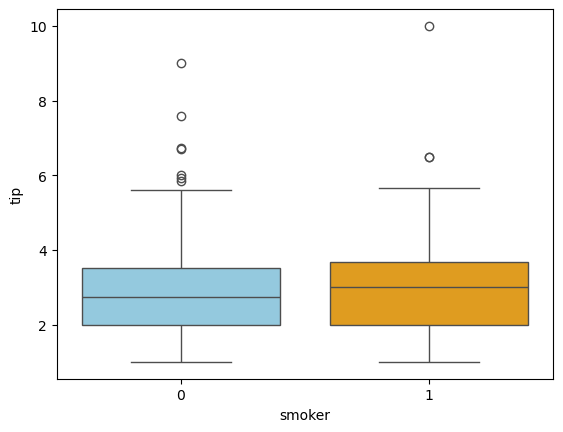

In [30]:
# distribucion de la propina (tip) segun si es fumador o no 
sns.boxplot(x='smoker', y='tip', data=datap,
           hue='smoker',
           palette=['skyblue', 'orange'],
           legend=False)
plt.show()

sex     Female  Male
smoker              
0           54    97
1           33    60


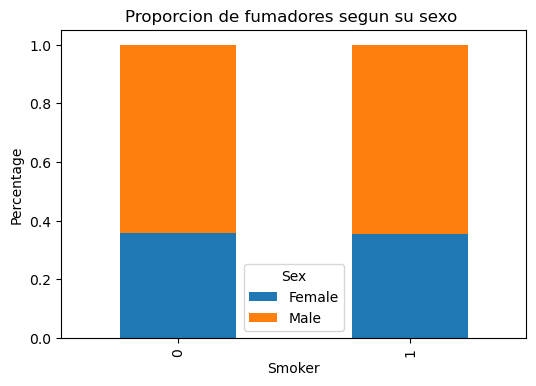

In [31]:
# tabla de contingencia: sexo vs fumador de acuerdo a las cantidades 
print (pd.crosstab(datap["smoker"], datap["sex"]))
# en porcentajes para ver que proporcion de cada grupo 
Sexo = pd.crosstab(datap["smoker"], datap["sex"])
Sexo_percentage = Sexo.div(
    Sexo.sum(axis=1).astype(float),
    axis=0
)
Sexo_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)
plt.xlabel("Smoker")
plt.ylabel("Percentage")
plt.title("Proporcion de fumadores segun su sexo ")
plt.legend(title="Sex")
plt.show()



### separar variables predictoras (X) y variable objetivo (Y)

In [32]:
# X solo la columnas predictoras: total_bill y tip 
X = datap[['total_bill','tip']].values

In [33]:
y = datap['smoker'].values
# objetivoo: 0 no fuma / 1 si fuman 

In [34]:
X[0:5]

array([[16.99,  1.01],
       [10.34,  1.66],
       [21.01,  3.5 ],
       [23.68,  3.31],
       [24.59,  3.61]])

In [35]:
y[0:5]

array([0, 0, 0, 0, 0])

## DIVISION PARA ENTRENAMIENTO Y PRUEBA 

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)

## ENTRENAR MODELO NAIVE BAYES GAUSSIANO 

In [37]:
classifier = GaussianNB().fit(X_train, y_train)

In [38]:
# predicciones del modelo sobre los datos de prueba
y_pred = classifier.predict(X_test)

In [39]:
y_pred[0:5] # muestra las 5 primera predicciones 

array([0, 0, 0, 0, 0])

In [40]:
y_test[0:5]

array([0, 1, 0, 0, 1])

## matriz de confusion ( sirve para comparar lo que el modelo predijo)

In [41]:
confusion_matrix(y_test, y_pred)

array([[26,  2],
       [20,  1]])

Matriz de Confusión, sin normalización
[[26  2]
 [20  1]]
Matriz de Confusión Normalizada
[[0.92857143 0.07142857]
 [0.95238095 0.04761905]]


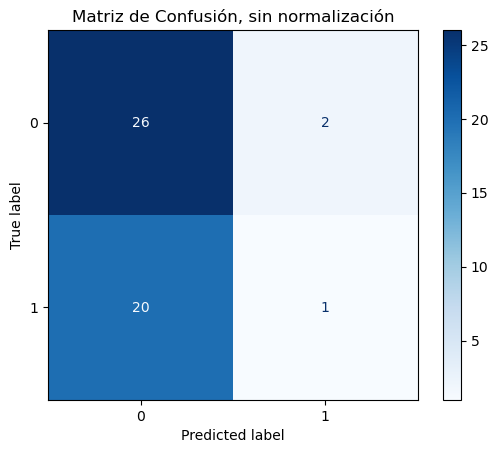

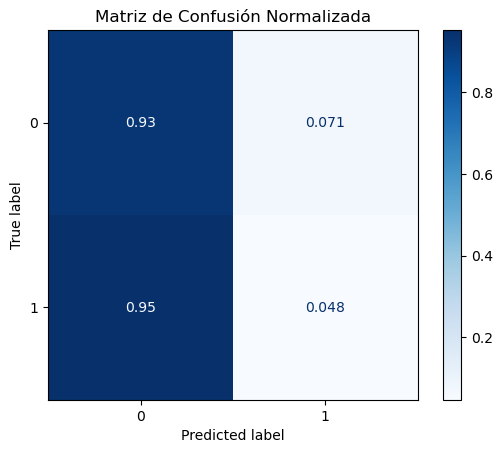

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
titles_options = [
  ("Matriz de Confusión, sin normalización", None),
  ("Matriz de Confusión Normalizada", "true")
]

for title, normalize in titles_options:
  disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    classifier.predict(X_test),
    cmap=plt.cm.Blues,
    normalize=normalize

  )
  disp.ax_.set_title(title)
  print(title)
  print(disp.confusion_matrix)
plt.show()

## PROBABILIDDES Y CURVA ROC 

In [43]:
# PROBABILIDAD DE CADA CLASE (COLUMA: 0 NO FUMA / 1 SI FUMAN)

y_pred_prob = classifier.predict_proba(X_test)

In [44]:
# mostrar 5 filas de probabilidad
y_pred_prob[0:5]

array([[0.71450358, 0.28549642],
       [0.69349906, 0.30650094],
       [0.69491517, 0.30508483],
       [0.66652951, 0.33347049],
       [0.7176657 , 0.2823343 ]])

In [45]:
# para ver la probabilidad de clase positiva 1 (si fuma)
y_pred_prob[0:5, 1]

array([0.28549642, 0.30650094, 0.30508483, 0.33347049, 0.2823343 ])

In [46]:
# para ver la probabilidad de clase negativa 0 (no fuma)
y_pred_prob[0:5, 0]

array([0.71450358, 0.69349906, 0.69491517, 0.66652951, 0.7176657 ])

In [47]:
false_positive_rate, true_positive_rate, thresholds= roc_curve(
    y_test, y_pred_prob[:,1]
)

In [48]:
roc_auc = auc(false_positive_rate, true_positive_rate)
roc_auc

0.5170068027210885

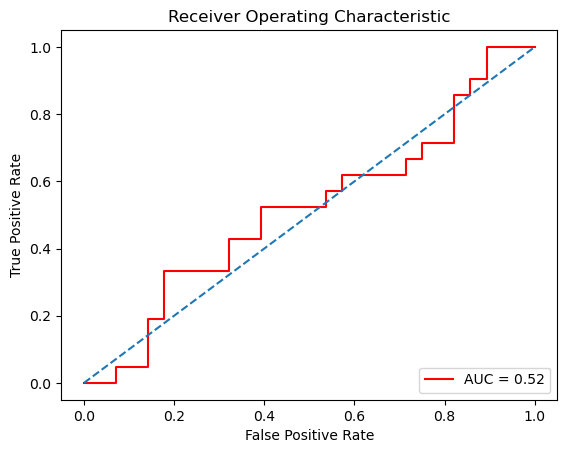

In [49]:
plt.title('Receiver Operating Characteristic')
plt.plot(false_positive_rate, true_positive_rate, color='red',
     label='AUC = %0.2f' % roc_auc)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--') 
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [50]:

dataff = pd.concat([
    pd.DataFrame(X_test),
    pd.DataFrame(y_test),
    pd.DataFrame(y_pred),
    pd.DataFrame(y_pred_prob)
],axis = 1 )

In [51]:
dataff.head(5)

,0,1,0,0,0,1
0,17.59,2.64,0,0,0.714504,0.285496
1,18.29,3.76,1,0,0.693499,0.306501
2,19.49,3.51,0,0,0.694915,0.305085
3,7.25,1.00,0,0,0.666530,0.333470
4,16.27,2.50,1,0,0.717666,0.282334


In [53]:
# renombrar las columnas:
dataff.columns=['Total_Bill','Tip','Smoker','Smoker_pred','Smoker_pred_prob_0','Smoker_pred_prob_1']


In [54]:
dataff.head(10)

,Total_Bill,Tip,Smoker,Smoker_pred,Smoker_pred_prob_0,Smoker_pred_prob_1
0,17.59,2.64,0,0,0.714504,0.285496
1,18.29,3.76,1,0,0.693499,0.306501
2,19.49,3.51,0,0,0.694915,0.305085
3,7.25,1.00,0,0,0.666530,0.333470
4,16.27,2.50,1,0,0.717666,0.282334
5,5.75,1.00,1,0,0.651260,0.348740
6,17.92,3.08,1,0,0.709127,0.290873
7,23.33,5.65,1,0,0.562095,0.437905
8,18.15,3.50,1,0,0.700607,0.299393
9,34.65,3.68,1,1,0.463607,0.536393
